In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [4]:
RESULTS_DIR = Path("/home/vivekbisht/Desktop/faers-signal-detection/results_private")
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR=RESULTS_DIR / "prr_validation_results.csv"

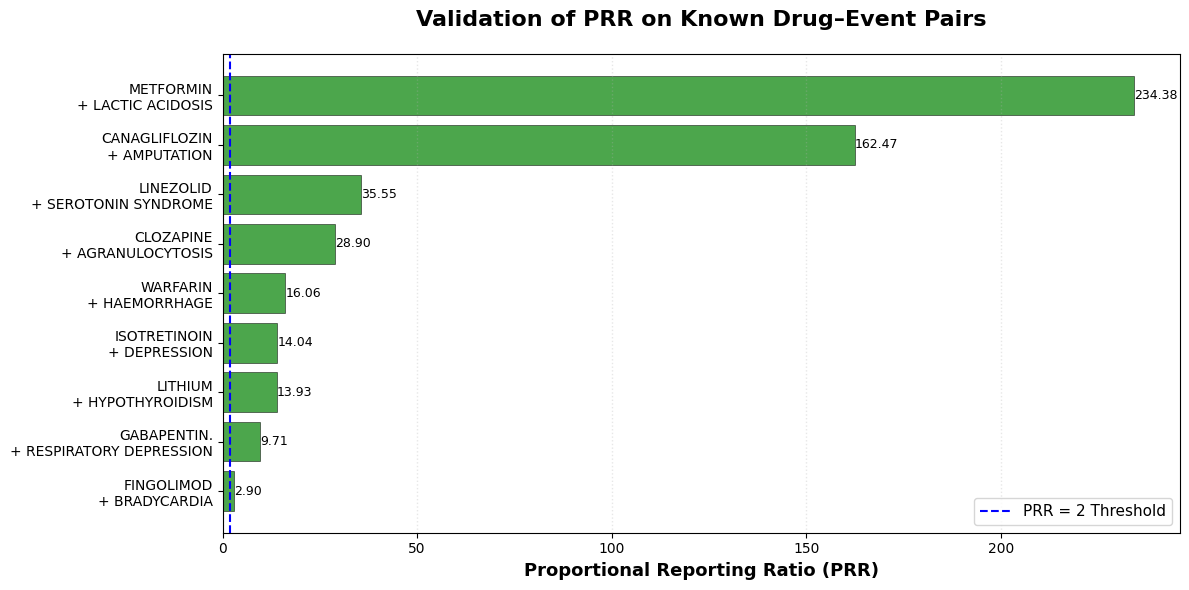

In [ ]:
validation = pd.read_csv(FIG_DIR)

validation = validation.sort_values('prr', ascending=True).reset_index(drop=True)

fig_height = max(6, len(validation) * 0.45)
fig, ax = plt.subplots(figsize=(12, fig_height))

colors = ['green' if x else 'red' for x in validation['is_signal']]

bars = ax.barh(
    range(len(validation)),
    validation['prr'],
    color=colors,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

ax.set_yticks(range(len(validation)))
ax.set_yticklabels(
    [f"{row['drug']}\n+ {row['event'][:40]}"
     for _, row in validation.iterrows()],
    fontsize=10
)

ax.set_xlabel('Proportional Reporting Ratio (PRR)', fontsize=13, fontweight='bold')
ax.set_title(
    'Validation of PRR on Known Drug–Event Pairs',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axvline(2, color='blue', linestyle='--', label='PRR = 2 Threshold')

for i, prr in enumerate(validation['prr']):
    ax.text(prr + 0.05, i, f"{prr:.2f}", va='center', fontsize=9)

ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "prr_validation_plot.png", dpi=300)
plt.show()